# Модуль decimal

* ``Decimal`` – десятичное число, для выполнения точных расчетов;
* ``Fraction`` – число, представляющее собой обыкновенную дробь, с заданным числителем и знаменателем;
* ``Complex``– комплексное число.

**Тип данных float**

In [ ]:
if 0.3 == 0.3:
    print('YES')
else:
    print('NO')

In [ ]:
num = 0.1 + 0.1 + 0.1

if num == 0.3:
    print('YES')
else:
    print('NO')

Вы будете удивлены, но результатом выполнения такого кода будет ``NO``, так как на самом деле в переменной num хранится что-то типа 
**0.30000000000000004**.

Из-за ограничений в сохранении точного значения чисел, даже простейшие математические операции могут выдавать ошибочный результат. Поэтому, чтобы сравнивать два ``float`` числа мы должны использовать такой код:

In [2]:
num = 0.1 + 0.1 + 0.1
eps = 0.000000001           # точность сравнения

if abs(num - 0.3) < eps:    # число num отличается от числа 0.3 менее чем 0.000000001
    print('YES')
else:
    print('NO')

YES


**Не стоит сравнивать ``float`` числа с помощью оператора ``==``. Для сравнения ``float`` чисел нужно использовать указанный выше код.**

## Тип данных Decimal

Тип данных ``Decimal`` – это класс из стандартного модуля ``decimal``. Он представляет собой число с плавающей точкой, как и ``float``. Однако, ``Decimal`` имеет ряд существенных отличий от ``float``.

Тип Decimal создан, чтобы операции над вещественными числами в компьютере выполнялись как в математике, и равенство 
```
0.1+0.1+0.1==0.3
```
было верным.

В Python тип данных float реализован по стандарту IEEE-754 как число с плавающей точкой двойной точности (64 бита) с основанием экспоненты равным 2.

Реализация таких чисел заложена прямо в железо любого современного процессора. Поэтому ``float`` в Python работает как аналогичный тип данных ``double`` в таких языках программирования как С#, С++, Java и т.д. И имеет такие же ограничения и «странности». Так как float поддерживается аппаратно, быстродействие при использовании этого типа данных сравнительно велико.

Тип данных ``Decimal`` – число с плавающей точкой с основанием экспоненты 10. Он реализован по стандарту IBM: General Decimal Arithmetic Specification, в свою очередь основанному на стандартах IEEE.

Тип данных ``Decimal`` реализован программно, поэтому он в разы медленнее типа данных ``float``, реализованного аппаратно. Сам тип данных ``Decimal`` написан на языке С.



Тип данных ``Decimal`` оперирует числами с произвольной – задаваемой программистом, но конечной точностью. По умолчанию точность составляет 
28 десятичных знаков.

Тип данных **``Decimal`` неизменяемый**. Операции над ним приводят к созданию новых объектов, при этом старые не меняются.

Для типа данных ``Decimal`` можно настроить:

* точность выполнения операций в количестве десятичных знаков;
* режимы округления;
* режимы обработки исключительных ситуаций (деление на ноль, переполнение и т. д).

**Создание Decimal чисел**

In [ ]:
from decimal import *

d1 = Decimal(1)
d2 = Decimal(567)
d3 = Decimal(-93)
d4 = Decimal('12345')
d5 = Decimal('52.198')

print(d1, d2, d3, d4, d5, sep='\n')

In [ ]:
from decimal import *

num = Decimal(0.1)

print(num)

In [ ]:
from decimal import *

num1 = Decimal('5.2')
num2 = Decimal('2.3')

print(num1 + num2)
print(num1 - num2)
print(num1 * num2)
print(num1 / num2)
print(num1 // num2)
print(num1 ** num2)

In [ ]:
from decimal import *

num = Decimal('5.2')

print(num + 1)
print(num - 10)
print(num * 2)
print(num ** 4)

In [ ]:
from decimal import *
from math import *

num1 = Decimal('1.44')
num2 = Decimal('0.523')

print(sqrt(num1))
print(sin(num2))
print(log(num1 + num2))

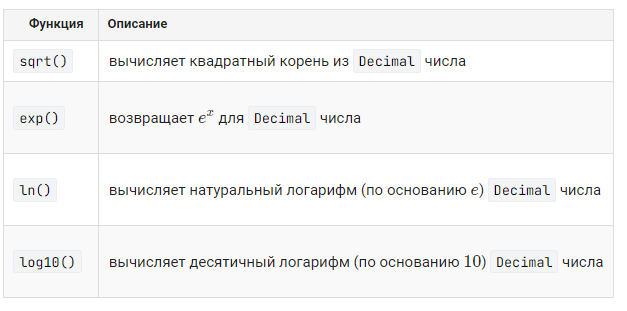

In [ ]:
from decimal import *

num = Decimal('10.0')

print(num.sqrt())
print(num.exp())
print(num.ln())
print(num.log10())

Тип данных Decimal также содержит полезный метод as_tuple() который возвращает кортеж из 
3 элементов:

* ``sign`` – знак числа (0 для положительного числа и 1 для отрицательного числа);
* ``digits`` – цифры числа;
* ``exponent`` – значение экспоненты (количество цифр после точки, умноженное на −1)

In [ ]:
from decimal import *

num1 = Decimal('-1.4568769017')
num2 = Decimal('0.523')

print(num1.as_tuple())
print(num2.as_tuple())

In [ ]:
from decimal import *

num = Decimal('-1.4568769017')
num_tuple = num.as_tuple()

print(num_tuple.sign)
print(num_tuple.digits)
print(num_tuple.exponent)

**Работа с контекстом Decimal чисел**

In [ ]:
from decimal import *

print(getcontext())

In [ ]:
from decimal import *

getcontext().prec = 3      # устанавливаем точность в 3 знака

num = Decimal('3.1415')

print(num)
print(num * 1)
print(num * 2)
print(num / 2)

**Округление чисел**

In [ ]:
from decimal import *

getcontext().prec = 4                    # устанавливаем точность числа

num = Decimal('3.1415926535')

print(num.quantize(Decimal('1.000')))    #  округление до 3 цифр в дробной части  
print(num.quantize(Decimal('1.00')))     #  округление до 2 цифр в дробной части
print(num.quantize(Decimal('1.0')))      #  округление до 1 цифр в дробной части

* ``ROUND_CEILING`` – округление в направлении бесконечности (Infinity);
* ``ROUND_FLOOR`` – округляет в направлении минус бесконечности (- Infinity);
* ``ROUND_DOWN`` – округление в направлении нуля;
* ``ROUND_HALF_EVEN`` – округление до ближайшего четного числа, число 6.5 округлится не до 7, а до 6;
* ``ROUND_HALF_DOWN`` – округление до ближайшего нуля;
* ``ROUND_UP`` – округление от нуля;
* ``ROUND_05UP`` – округление от нуля (если последняя цифра после округления до нуля была бы 0 или 5, в противном случае к нулю).

In [ ]:
from decimal import *

num = Decimal('3.456')

print(num.quantize(Decimal('1.00'), ROUND_CEILING))
print(num.quantize(Decimal('1.00'), ROUND_FLOOR))

**Сравнение float и Decimal чисел**

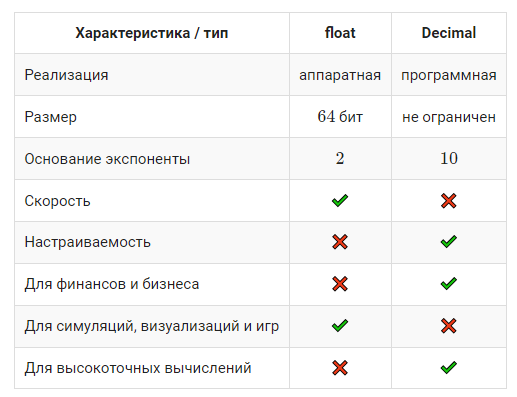

Примечание 1. Decimal числа можно сравнивать между собой, как обычные числа, причем в отличие от float чисел допускается и точное равенство.

In [ ]:
from decimal import *

num = Decimal('0.1')
if num*3 == Decimal('0.3'):
    print('YES')
else:
    print('NO')

Примечание 2. Можно сортировать списки с Decimal числами и искать минимум и максимум среди них.

In [ ]:
from decimal import *

s = '1.34 3.45 1.00 0.03 9.25'

numbers = [Decimal(i) for i in s.split()]

maximum = max(numbers)
minimum = min(numbers)

numbers.sort()

print(maximum)
print(minimum)
print(numbers)

In [ ]:
from decimal import *

num = Decimal('0.1') + Decimal('0.1') + Decimal('0.1') - Decimal('0.3')

if num == 0:
    print('YES')
else:
    print('NO')

In [ ]:
s = '9.73 8.84 8.92 9.60 9.32 8.97 8.53 1.26 6.62 9.85 1.85 1.80 0.83 6.75 9.74 9.11 9.14 5.03 5.03 1.34 3.52 8.09 7.89 8.24 8.23 5.22 0.30 2.59 1.25 6.24 2.14 7.54 5.72 2.75 2.32 2.69 9.32 8.11 4.53 0.80 0.08 9.36 5.22 4.08 3.86 5.56 1.43 8.36 6.29 5.13'

from decimal import *

s=[Decimal(i) for i in s.split()]

s=sorted(s,reverse=True)
print(max(s)+min(s))
print(*s[:5])

## Модуль fractions

Рациональное число – это число, которое можно представить в виде дроби 
n,
m
​
 , где 
,
m,n соответственно, числитель и знаменатель, которые имеют целочисленное значение, при этом знаменатель не равен нулю.

Для работы с рациональными числами в Python используется тип данных Fraction. Тип данных Fraction как и Decimal реализован программно, поэтому он в разы медленнее встроенных числовых типов данных int и float. Тип данных Fraction неизменяемый. Операции над данными этого типа приводят к созданию новых объектов, при этом старые не меняются.

Создать Fraction число можно несколькими способами:

* из целых чисел, передав значения числителя и знаменателя дроби,
* из строки на основании десятичного представления;
* из строки на основании обыкновенной дроби;
* из числа с плавающей точкой (не рекомендуется).

In [ ]:
from fractions import Fraction

num1 = Fraction(3, 4)     # 3 - числитель, 4 - знаменатель
num2 = Fraction('0.55')
num3 = Fraction('1/9')

print(num1, num2, num3, sep='\n')

In [ ]:
from fractions import Fraction

num = Fraction(0.34)

print(num)

In [ ]:
from fractions import Fraction

num1 = Fraction(5, 10)
num2 = Fraction('75/100')
num3 = Fraction('0.25')

print(num1, num2, num3, sep='\n')

In [ ]:
from fractions import Fraction

num1 = Fraction(5, 1)        # 5/1 = 5
num2 = Fraction(23, 23)      # 23/23 = 1

print(num1, num2, sep='\n')

``Fraction`` числа можно сравнивать между собой точно так же, как и любые другие числа. Доступны 
6 основных операторов сравнения:

* ``>``: больше;
* ``<``: меньше;
* ``>=``: больше либо равно;
* ``<=``: меньше либо равно;
* ``==``:  в точности равно;
* ``!=``: не равно.

In [ ]:
from fractions import Fraction

num1 = Fraction(1, 2)        # 1/2
num2 = Fraction(15, 30)      # 15/30=1/2
num3 = Fraction(3, 5)        # 3/5
num4 = Fraction(5, 3)        # 5/3
num5 = 1
num6 = 0.8


print(num1 == num2)
print(num1 != num4)
print(num2 > num3)
print(num4 <= num1)
print(num1 < num5)
print(num6 > num4)

In [ ]:
from fractions import Fraction

num1 = Fraction('1/10')
num2 = Fraction('2/3')

print(num1 + num2)
print(num1 - num2)
print(num1 * num2)
print(num1 / num2)

In [ ]:
from fractions import Fraction

num = Fraction('3/8')

print(num + 1)
print(num - 1)
print(num * 2)
print(num ** 4)

In [ ]:
from fractions import Fraction

num1 = Fraction('3/8')
num2 = Fraction('1/2')

print(num1 ** num2)

In [ ]:
from fractions import Fraction
from math import *

num1 = Fraction('1.44')
num2 = Fraction('0.523')

print(sqrt(num1))
print(sin(num2))
print(log(num1 + num2))

In [4]:
from fractions import Fraction

num = Fraction('5/16')

print('Числитель дроби равен:', num.numerator)
print('Знаменатель дроби равен:', num.denominator)

Числитель дроби равен: 5
Знаменатель дроби равен: 16


In [ ]:
from fractions import Fraction

num = Fraction('-5/16')

print(num.as_integer_ratio())

In [ ]:
from fractions import Fraction
import math

print('PI =', math.pi)

num = Fraction(str(math.pi))

print('No limit =', num)

for d in [1, 5,  50, 90, 100, 500, 1000000]:
    limited = num.limit_denominator(d)
    print(limited)

Примечание 1. Для того, чтобы каждый раз не писать название типа, можно использовать следующий код:

In [ ]:
from fractions import Fraction as F

num1 = F('1/5') + F('3/2')
num2 = F('1/4') * F('2/5')

print(num1)
print(num2)

Примечание 3. В Python нельзя совершать арифметические операции (+, -, *, /) между типами Decimal и Fraction.

In [ ]:
from decimal import Decimal
from fractions import Fraction

num1 = Decimal('12.5')
num2 = Fraction(19, 3)

print(num1 + num2)

In [ ]:
from fractions import *

num = Fraction(7, 71)

if num * 71 == 7:
    print('YES')
else:
    print('NO')

In [ ]:
from fractions import Fraction

numbers = ['6.34', '4.08', '3.04', '7.49', '4.45', '5.39', '7.82', '2.76', '0.71', '1.97', '2.54', '3.67', '0.14', '4.29', '1.84', '4.07', '7.26', '9.37', '8.11', '4.30', '7.16', '2.46', '1.27', '0.29', '5.12', '4.02', '6.95', '1.62', '2.26', '0.45', '6.91', '7.39', '0.52', '1.88', '8.38', '0.75', '0.32', '4.81', '3.31', '4.63', '7.84', '2.25', '1.10', '3.35', '2.05', '7.87', '2.40', '1.20', '2.58', '2.46']

fracs=[Fraction(i) for i in numbers]
for i in range(len(numbers)):
    print(str(numbers[i])+'='+str(fracs[i]))


In [ ]:
# put your python code here
from fractions import Fraction

x,y=[Fraction(input()) for i in range(2)]

print(Fraction(x,y))

In [ ]:
from fractions import Fraction as F
from math import factorial

n=int(input())
iii=[i for i in range(n+1)[1:]]
print(iii)
jjj=[n-j for j in iii][:-1]
print(jjj)

fff=[(iii[k],jjj[k]) for k in range(0,n-2)]

# for i in fff:
#     if i

In [ ]:
lll=[]
for i in range(len(fff)):
    if float(fff[i][0]/fff[i][1]).is_integer():
        pass
    elif F(fff[i][0],fff[i][1]).as_integer_ratio()[0]+F(fff[i][0],fff[i][1]).as_integer_ratio()[1]!=n:
        pass
    elif fff[i][0]>fff[i][1]:
        pass
    else:
        lll.append(F(fff[i][0],fff[i][1]))

In [ ]:
F(fff[1][0],fff[1][1]).as_integer_ratio()[0]+F(fff[1][0],fff[1][1]).as_integer_ratio()[1]!=n

In [ ]:
from fractions import Fraction as F
from math import factorial

n=int(input())
iii=[i for i in range(n+1)[1:]]

jjj=[n-j for j in iii][:-1]


fff=[(iii[k],jjj[k]) for k in range(0,n-2)]

lll=[]
for i in range(len(fff)):
    if float(fff[i][0]/fff[i][1]).is_integer():
        pass
    elif F(fff[i][0],fff[i][1]).as_integer_ratio()[0]+F(fff[i][0],fff[i][1]).as_integer_ratio()[1]!=n:
        pass
    elif fff[i][0]>fff[i][1]:
        pass
    else:
        lll.append(F(fff[i][0],fff[i][1]))
print(max(lll))

In [ ]:
# put your python code here
from fractions import Fraction as F
from math import factorial

n=int(input())
iii=[i for i in range(n+1)[1:]]

jjj=[n-j for j in iii][:-1]


fff=[(iii[k],jjj[k]) for k in range(0,n-2)]

lll=[]
for i in range(len(fff)):
    if float(fff[i][0]/fff[i][1]).is_integer():
        pass
    elif F(fff[i][0],fff[i][1]).as_integer_ratio()[0]+F(fff[i][0],fff[i][1]).as_integer_ratio()[1]!=n:
        pass
    elif fff[i][0]>fff[i][1]:
        pass
    else:
        lll.append(F(fff[i][0],fff[i][1]))
print(sorted(lll))

In [ ]:
from fractions import Fraction as F
from math import factorial

n=int(input())
z=[]
for i in range(1,n+1):
    for j in range(1,n+1):
        z.append([j,i])


def is_good_drob(fff):
    if float(fff[0]/fff[1]).is_integer():
        return False
    elif fff[0]>fff[1]:
        return False
    else:
        return True

lll=[]
for i in range(len(z)):
    if is_good_drob(z[i]):
        lll.append(F(z[i][0],z[i][1]))
lll=list(set(lll))
for i in sorted(lll):
    print(i)